# GAMM Pipeline (IRT)

## Setup
### Imports and Paths

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

%load_ext rpy2.ipython

INPUT_CSV = Path(r"C:\Users\eva\Documents\Master\ICM\Ilo\GAMM\02_intervalles.csv")
OUT_DIR   = Path(r"C:\Users\eva\Documents\Master\ICM\Ilo\GAMM\output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR_STR = str(OUT_DIR)

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


### Load & clean data

In [2]:
df = pd.read_csv(INPUT_CSV)
df = df[df["valid"]].copy()
print(f"Loaded {len(df)} rows, {df['subname'].nunique()} subjects")

Loaded 1711 rows, 13 subjects


### Feature engineering

In [3]:
df = df.sort_values(["subname", "session", "interval_idx"]).reset_index(drop=True)
grp = ["subname", "session"]

is_reset = df["anchor_event"] == "Reset"
is_probe = df["anchor_event"] == "EndProbe"

df = df.drop(columns=["valid", "exclusion"], errors="ignore")

# Number of resets/probes that already happened before this interval started
df["reset_count"] = is_reset.groupby([df["subname"], df["session"]]).cumsum()
df["reset_count"] = df.groupby(grp)["reset_count"].shift(1).fillna(0)

df["probe_count"] = is_probe.groupby([df["subname"], df["session"]]).cumsum()
df["probe_count"] = df.groupby(grp)["probe_count"].shift(1).fillna(0)

In [4]:
# Time since the last reset / probe
df["_reset_time_raw"] = df["t_start_s"].where(is_reset)
df["_reset_time_ffill"] = df.groupby(grp)["_reset_time_raw"].ffill()
df["_probe_time_raw"] = df["t_start_s"].where(is_probe)
df["_probe_time_ffill"] = df.groupby(grp)["_probe_time_raw"].ffill()
df["_session_start"] = df.groupby(grp)["t_start_s"].transform("first")

df["time_since_last_reset"] = df["t_start_s"] - df["_reset_time_ffill"].fillna(df["_session_start"])
df["time_since_last_probe"] = df["t_start_s"] - df["_probe_time_ffill"].fillna(df["_session_start"])

# Right-skewed -> log1p
df["log_time_since_reset"] = np.log1p(df["time_since_last_reset"])
df["log_time_since_probe"] = np.log1p(df["time_since_last_probe"])

df = df.drop(columns=["scorer", "_reset_time_raw", "_reset_time_ffill",
                       "_probe_time_raw", "_probe_time_ffill", "_session_start"])
df.head()

,subname,session,session_raw,interval_idx,anchor_event,t_start_s,t_end_s,t_mid_min,irt_s,irt_error_s,...,irt_roll,cv_roll_pct,t_exp_s,t_exp_min,reset_count,probe_count,time_since_last_reset,time_since_last_probe,log_time_since_reset,log_time_since_probe
0,TT001,Nap1,Session 4,1,Response,36.4626,70.5442,0.8917,34.0816,4.0816,...,NaN,NaN,1199.6434,19.9941,0.0,0.0,0.0000,0.0000,0.000000,0.000000
1,TT001,Nap1,Session 4,2,Response,70.5442,108.2023,1.4896,37.6581,7.6581,...,35.8698,7.050,1235.5133,20.5919,0.0,0.0,34.0816,34.0816,3.557677,3.557677
2,TT001,Nap1,Session 4,3,Response,108.2023,148.3807,2.1382,40.1784,10.1784,...,37.3060,8.212,1274.4315,21.2405,0.0,0.0,71.7397,71.7397,4.286887,4.286887
3,TT001,Nap1,Session 4,4,Response,148.3807,185.4366,2.7818,37.0559,7.0559,...,37.2435,6.725,1313.0487,21.8841,0.0,0.0,111.9181,111.9181,4.726663,4.726663
4,TT001,Nap1,Session 4,5,Response,185.4366,218.8346,3.3689,33.3980,3.3980,...,36.4744,7.589,1348.2756,22.4713,0.0,0.0,148.9740,148.9740,5.010462,5.010462


In [5]:
Subjects = ["TT001", "TT002", "TT003", "TT004", "TT005", "TT006", "TT007", "TT008"]
df_clean = df.copy()
df_clean = df_clean.where(df_clean["subname"].isin(Subjects)).dropna().reset_index(drop=True)
df = df_clean

## Stage 0: Exploratory checks

In [7]:
%%R -w 1000 -h 450
print(aggregate(irt_error_s ~ session_f, data = df,
                 FUN = function(x) c(mean = mean(x), sd = sd(x), n = length(x))))
par(mfrow = c(1, 2))
hist(df$irt_error_s, breaks = 40, col = "grey80",
     main = "irt_error_s -- distribution", xlab = "irt_error_s (s)")
boxplot(irt_error_s ~ session_f, data = df, col = "lightblue",
        main = "irt_error_s by session", xlab = "session", ylab = "irt_error_s (s)")
dev.copy(png, file.path(out_dir, "eda_outcome_distribution.png"), width = 1200, height = 500, res = 120)
dev.off()

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xea in position 92: invalid continuation byte <traceback object at 0x000002C026A8D000>



'utf-8' codec can't decode byte 0xea in position 92: invalid continuation byte


RInterpreterError: Failed to parse and evaluate line 'print(aggregate(irt_error_s ~ session_f, data = df,\n                 FUN = function(x) c(mean = mean(x), sd = sd(x), n = length(x))))\npar(mfrow = c(1, 2))\nhist(df$irt_error_s, breaks = 40, col = "grey80",\n     main = "irt_error_s -- distribution", xlab = "irt_error_s (s)")\nboxplot(irt_error_s ~ session_f, data = df, col = "lightblue",\n        main = "irt_error_s by session", xlab = "session", ylab = "irt_error_s (s)")\ndev.copy(png, file.path(out_dir, "eda_outcome_distribution.png"), width = 1200, height = 500, res = 120)\ndev.off()\n'.
R error message: "'utf-8' codec can't decode byte 0xea in position 92: invalid continuation byte"

png 
  2 


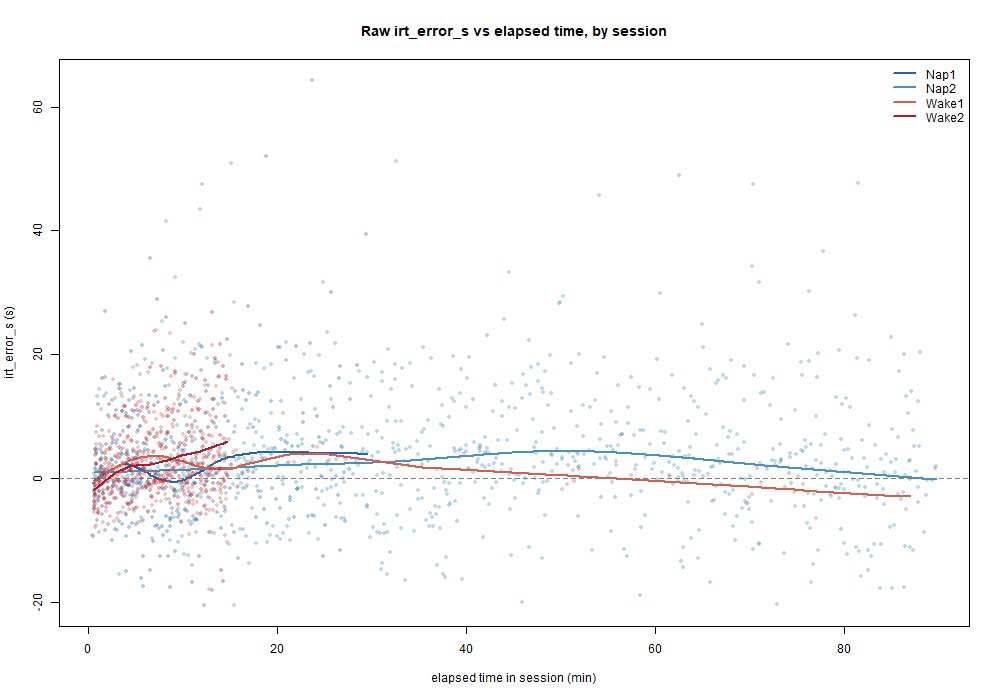

In [ ]:
%%R -w 1000 -h 700
sess_levels <- levels(df$session_f)
sess_cols   <- setNames(c("#2166AC", "#4393C3", "#D6604D", "#B2182B")[seq_along(sess_levels)],
                         sess_levels)
plot(df$t_mid_min, df$irt_error_s, type = "n",
     xlab = "elapsed time in session (min)", ylab = "irt_error_s (s)",
     main = "Raw irt_error_s vs elapsed time, by session")
abline(h = 0, lty = 2, col = "grey50")
for (s in sess_levels) {
  sub <- df[df$session_f == s, ]
  points(sub$t_mid_min, sub$irt_error_s, pch = 16, cex = 0.7,
         col = adjustcolor(sess_cols[[s]], alpha.f = 0.35))
  lo <- lowess(sub$t_mid_min, sub$irt_error_s, f = 0.4)
  lines(lo, col = sess_cols[[s]], lwd = 2)
}
legend("topright", legend = sess_levels, col = sess_cols[sess_levels], lwd = 2, bty = "n")
dev.copy(png, file.path(out_dir, "eda_time_by_session.png"), width = 1000, height = 700, res = 120)
dev.off()

Different shapes, not just the same curve shifted up/down -> `by=session`in the model

## Stage 1: Null model 

No fixed predictors: just an overall mean plus a random intercept per subject. Every subject is modelled by its own Gaussian, all sharing the same spread/shape, just shifted.

In [ ]:
%%R
m0 <- bam(irt_error_s ~ s(subname, bs = "re"), data = df, method = "fREML")
summary(m0)


Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(subname, bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)    3.025      1.226   2.467   0.0137 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf Ref.df     F p-value    
s(subname) 11.64     12 31.87  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.183   Deviance explained = 18.8%
fREML =   6082  Scale est. = 69.845    n = 1711


- s(subname) : subjects differ from each other more than we would expect by chance
- intercept : mean of irt_error_s across all subjects
- Deviance explained : total variance in irt_error attributable to between-subject differences

## Stage 2: + elapsed time in session 
One shared smooth

In [ ]:
%%R
m1 <- bam(irt_error_s ~ s(t_mid_min, k = 10) + s(subname, bs = "re"),
          data = df, method = "fREML")
summary(m1)


Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(t_mid_min, k = 10) + s(subname, bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)    3.052      1.213   2.515    0.012 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                edf Ref.df      F p-value    
s(t_mid_min)  4.294   5.28  3.876 0.00137 ** 
s(subname)   11.632  12.00 31.222 < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.192   Deviance explained =   20%
fREML = 6076.1  Scale est. = 69.043    n = 1711


- edf of t_mid_min: signidicant nonlinear trend in irt_error_s over time

In [ ]:
%%R
cat(sprintf("AIC: M0 = %.1f   M1 = %.1f   (delta = %.1f)\n", AIC(m0), AIC(m1), AIC(m0) - AIC(m1)))

AIC: M0 = 12135.7   M1 = 12122.6   (delta = 13.1)


- positive delta -> m1 better than m0

## Stage 3 : Does the trajectory differ by session?

`by = session_f` gives each session its own smooth of `t_mid_min`

In [ ]:
%%R
m2 <- bam(irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f + s(subname, bs = "re"),
          data = df, method = "fREML")
summary(m2)



Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f + 
    s(subname, bs = "re")

Parametric coefficients:
               Estimate Std. Error t value Pr(>|t|)   
(Intercept)       5.432      1.918   2.833  0.00467 **
session_fNap2    -2.718      1.514  -1.795  0.07285 . 
session_fWake1   -1.610      1.647  -0.977  0.32854   
session_fWake2    7.564      2.809   2.693  0.00715 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df      F  p-value    
s(t_mid_min):session_fNap1   1.076  1.148  4.034   0.1017    
s(t_mid_min):session_fNap2   3.100  3.855  2.413   0.0524 .  
s(t_mid_min):session_fWake1  1.543  1.898  0.869   0.4926    
s(t_mid_min):session_fWake2  1.000  1.000 19.923 9.27e-06 ***
s(subname)                  11.627 12.000 31.261  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-s

- edf: Nap2 et Wake are the only sessions with nonlinear trends

In [ ]:
%%R
cat(sprintf("AIC: M1 = %.1f   M2 = %.1f   (delta = %.1f)\n", AIC(m1), AIC(m2), AIC(m1) - AIC(m2)))

AIC: M1 = 12122.6   M2 = 12117.5   (delta = 5.0)


## Stage 4: Random intercept vs. subject-specific smooth ("random slope")

`s(subname, bs="re")` only lets each subject's *overall level* differ. If subjects'
trajectories over elapsed time differ in *shape* (not just offset), a factor-smooth
interaction (`bs="fs"`) gives each subject their own penalized smooth of `t_mid_min`.

In [ ]:
%%R
m1_fs <- suppressWarnings(bam(irt_error_s ~ s(t_mid_min, k = 10) +
                            s(t_mid_min, subname, bs = "fs", k = 5, m = 1),
             data = df, method = "fREML"))
summary(m1_fs)


Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(t_mid_min, k = 10) + s(t_mid_min, subname, bs = "fs", 
    k = 5, m = 1)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)    3.186      1.263   2.522   0.0118 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                        edf Ref.df     F p-value    
s(t_mid_min)          2.868  3.417 0.999   0.389    
s(t_mid_min,subname) 43.867 64.000 9.640  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.275   Deviance explained = 29.5%
fREML = 6016.3  Scale est. = 61.944    n = 1711


- Deviance explained: way better when using subject-specific smooths

In [ ]:
%%R
cat(sprintf("\nAIC: M1 (random intercept) = %.1f   M1_fs (subject-specific smooth) = %.1f   (delta = %.1f)\n",
            AIC(m1), AIC(m1_fs), AIC(m1) - AIC(m1_fs)))


AIC: M1 (random intercept) = 12122.6   M1_fs (subject-specific smooth) = 11967.3   (delta = 155.3)


Adding session_f in the model:

In [ ]:
%%R
m3 <- suppressWarnings(bam(irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f +
                             s(t_mid_min, subname, bs = "fs", k = 5, m = 1),
            data = df, method = "fREML"))
summary(m3)


Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f + 
    s(t_mid_min, subname, bs = "fs", k = 5, m = 1)

Parametric coefficients:
               Estimate Std. Error t value Pr(>|t|)  
(Intercept)       8.382      4.666   1.797   0.0726 .
session_fNap2    -5.418      4.494  -1.206   0.2281  
session_fWake1   -5.116      4.755  -1.076   0.2820  
session_fWake2    4.323      5.143   0.840   0.4008  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df      F  p-value    
s(t_mid_min):session_fNap1   1.839  2.250  3.194 0.103087    
s(t_mid_min):session_fNap2   1.622  1.857  0.310 0.748158    
s(t_mid_min):session_fWake1  1.401  1.577  0.176 0.810453    
s(t_mid_min):session_fWake2  1.000  1.000 14.388 0.000155 ***
s(t_mid_min,subname)        43.629 64.000  9.701  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.0

- edf: edf of Nap2 drops -> it was earlier driven by subject-specific trends

In [ ]:
%%R
cat(sprintf("\nAIC: M2 (by-session only) = %.1f   M1_fs (subject-smooth only) = %.1f   M3 (both) = %.1f\n",
            AIC(m2), AIC(m1_fs), AIC(m3)))


AIC: M2 (by-session only) = 12117.5   M1_fs (subject-smooth only) = 11967.3   M3 (both) = 11961.4


## Stage 5: + reset/probe counts and time since last reset/probe

Beyond elapsed session time, does the *task structure* matter — how many resets/probes have
already happened (`reset_count`, `probe_count`), and how long ago the last one was
(`log_time_since_reset`, `log_time_since_probe`)? Add these as smooths on top of M3, the best
model so far.

In [ ]:
%%R
m4 <- suppressWarnings(bam(irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f +
                             s(t_mid_min, subname, bs = "fs", k = 5, m = 1) +
                             s(reset_count, k = 5) + s(probe_count, k = 5) +
                             s(time_since_last_reset, k = 5) + s(log_time_since_probe, k = 5),
            data = df, method = "fREML"))
summary(m4)


Family: gaussian 
Link function: identity 

Formula:
irt_error_s ~ s(t_mid_min, by = session_f, k = 10) + session_f + 
    s(t_mid_min, subname, bs = "fs", k = 5, m = 1) + s(reset_count, 
    k = 5) + s(probe_count, k = 5) + s(time_since_last_reset, 
    k = 5) + s(log_time_since_probe, k = 5)

Parametric coefficients:
               Estimate Std. Error t value Pr(>|t|)
(Intercept)       5.300      5.853   0.905    0.365
session_fNap2    -1.516      5.861  -0.259    0.796
session_fWake1   -3.840      5.810  -0.661    0.509
session_fWake2    2.563      6.191   0.414    0.679

Approximate significance of smooth terms:
                               edf Ref.df      F  p-value    
s(t_mid_min):session_fNap1   2.039  2.488  3.894  0.00734 ** 
s(t_mid_min):session_fNap2   1.439  1.615  9.175  0.00123 ** 
s(t_mid_min):session_fWake1  1.000  1.000  5.435  0.01986 *  
s(t_mid_min):session_fWake2  1.000  1.000 16.153 6.16e-05 ***
s(t_mid_min,subname)        42.095 64.000  8.902  < 2e-16 ***
s(r

In [ ]:
%%R
cat(sprintf("\nAIC: M3 (by-session + subject smooth) = %.1f   M4 (+ reset/probe counts & timing) = %.1f   (delta = %.1f)\n",
            AIC(m3), AIC(m4), AIC(m3) - AIC(m4)))


AIC: M3 (by-session + subject smooth) = 11961.4   M4 (+ reset/probe counts & timing) = 11943.6   (delta = 17.7)


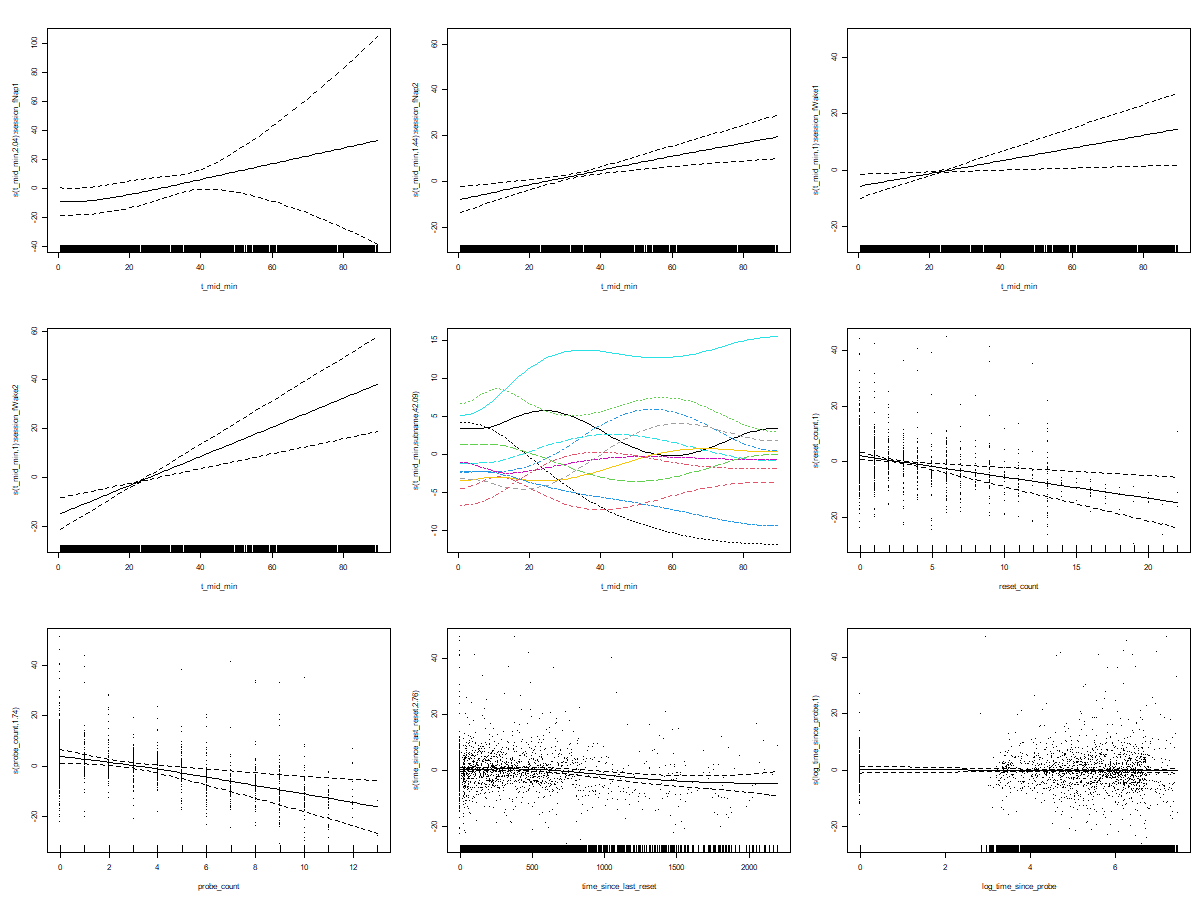

In [ ]:
%%R -w 1200 -h 900
png(file.path(out_dir, "gamm_smooths_m4.png"), width = 1200, height = 900, res = 120)
plot(m4, residuals = TRUE, pages = 1, shade = TRUE, seWithMean = TRUE, scale = 0)
dev.off()

plot(m4, residuals = TRUE, pages = 1, shade = TRUE, seWithMean = TRUE, scale = 0)

# Save models and plots

In [ ]:
%%R
png(file.path(out_dir, "gamm_check_plots.png"), width = 1000, height = 1000, res = 120)
sink(file.path(out_dir, "gamm_check_text.txt"))
cat(sprintf("=== gam.check(): %s ===\n", final_name))
gam.check(m_final)
sink()
dev.off()

png(file.path(out_dir, "gamm_smooths_final.png"), width = 1400, height = 700, res = 130)
plot(m_final, pages = 1, shade = TRUE, seWithMean = TRUE, scale = 0)
dev.off()

saveRDS(m0, file.path(out_dir, "m0_null.rds"))
saveRDS(m1, file.path(out_dir, "m1_time.rds"))
saveRDS(m2, file.path(out_dir, "m2_by_session.rds"))
saveRDS(m1_fs, file.path(out_dir, "m1_fs_subject_smooth.rds"))
saveRDS(m3, file.path(out_dir, "m3_by_session_and_subject_smooth.rds"))
saveRDS(m4, file.path(out_dir, "m4_reset_probe.rds"))
saveRDS(m_final, file.path(out_dir, "m_final.rds"))

cat("\nSaved to", out_dir, ":\n")
cat("  - eda_outcome_distribution.png, eda_time_by_session.png\n")
cat("  - gamm_check_plots.png / gamm_check_text.txt\n")
cat("  - gamm_smooths_final.png\n")
cat("  - m0_null.rds / m1_time.rds / m2_by_session.rds / m1_fs_subject_smooth.rds /\n")
cat("    m3_by_session_and_subject_smooth.rds / m4_reset_probe.rds / m_final.rds\n")


Saved to C:\Users\eva\Documents\Master\ICM\Ilo\GAMM\output :
  - eda_outcome_distribution.png, eda_time_by_session.png
  - gamm_check_plots.png / gamm_check_text.txt
  - gamm_smooths_final.png
  - m0_null.rds / m1_time.rds / m2_by_session.rds / m1_fs_subject_smooth.rds /
    m3_by_session_and_subject_smooth.rds / m4_reset_probe.rds / m_final.rds
